# RQ2 — Reproducibility: "Can I trust this number?"

Six questions on run-to-run stability of the two scores (PAWC_norm, AIS) across k=8 repeated runs.
Shared style, palette, data, the threshold-sweep helpers and validators live in the first code cell;
every figure below is one compact cell + a plain-English **Key analysis**. CLEANED metrics only.

In [1]:
# === RQ2 shared preamble: style (Visual_Style_Guide §13 + §5), data, sweep helpers, validators ===
import os, re, logging, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, leaves_list
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ---- §13 matplotlib global configuration block (verbatim) ----
# --- Font ---
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
# --- Axes ---
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.labelweight"] = "medium"
# --- Grid ---
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["axes.axisbelow"] = True
# --- Ticks ---
mpl.rcParams["xtick.direction"] = "out"
mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.size"] = 4
mpl.rcParams["ytick.major.size"] = 4
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
# --- Legend ---
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["legend.fontsize"] = 11
# --- Figure ---
mpl.rcParams["figure.figsize"] = (7, 4.5)
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["savefig.pad_inches"] = 0.15
# --- Engine palette ---
ENGINE_COLOURS = {
    "chatgpt":    "#2CA058",
    "claude":     "#D97706",
    "gemini":     "#2563EB",
    "kimi":       "#7C3AED",
    "perplexity": "#0891B2",
}
ENGINE_ORDER = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS = {
    "chatgpt":    "ChatGPT",
    "claude":     "Claude",
    "gemini":     "Gemini",
    "kimi":       "Kimi",
    "perplexity": "Perplexity",
}
ENGINE_MARKERS = {
    "chatgpt":    "o",
    "claude":     "s",
    "gemini":     "^",
    "kimi":       "D",
    "perplexity": "X",
}
# --- Supplementary colours ---
COLOUR_PRIMARY   = "#1F4E79"
COLOUR_NEUTRAL   = "#6B7280"
COLOUR_REFERENCE = "#DC2626"
COLOUR_GRID      = "#E5E7EB"
# --- Sequential heatmap ramp (teal-blue) ---
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("teal_sequential", ["#EAF0F7", "#5B8AC4", "#1F4E79"])
CMAP_SEQUENTIAL.set_bad("#D1D5DB")
# --- Divergent ramp (amber-brown -> white -> teal) for signed quantities ---
CMAP_DIVERGENT = LinearSegmentedColormap.from_list("teal_divergent", ["#B45309", "#F3F4F6", "#1F4E79"])

# ---- §5 apply_style ----
def apply_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151")
    ax.spines["bottom"].set_color("#374151")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

# ---- data load ----
GOLD = "../../data/scaleup/gold"; FIGDIR = "../../figures/scaleup/rq"; os.makedirs(FIGDIR, exist_ok=True)
ca  = pd.read_parquet(f"{GOLD}/cell_aggregates_scaleup.parquet")                 # per-cell workhorse, 1,249 rows
sil = pd.read_parquet("../../data/scaleup/silver/nli_scaleup_cleaned.parquet")   # per-run + sentence_detail, 9,992 rows
# NOTE: this is a gold artifact stored in silver/ — reconcile path

# ---- helpers ----
def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print("saved", name)

def by_engine(s):
    return s.reindex(ENGINE_ORDER)

# ---- threshold-sweep helpers (verbatim logic from scripts/pp_step7_threshold_sweep.py) ----
def is_artifact(t):
    t = t.strip()
    if not t: return True
    if re.match(r'^https?://\S+$', t): return True
    if t.startswith('#'): return True
    if re.match(r'^[-*=_]{3,}\s*$', t): return True
    if re.match(r'^(sources?|references?|citations?)\s*:?\s*$', t, re.IGNORECASE): return True
    if len(t.split()) <= 3: return True
    if re.match(r'^[\#\-\*\d\.\s]{1,10}$', t): return True
    return False

def _parse(v):
    return v.tolist() if isinstance(v, np.ndarray) else v

def survivors_of(sd):
    out = []
    for s in _parse(sd):
        if is_artifact(s.get("text", "")): continue
        sc = [float(x["score"]) for x in (_parse(s.get("source_scores")) or [])]
        out.append((int(s.get("wc", 0)), sc))
    return out

def metrics_at(sv, m, tau):
    """(cleaned_ais, pawc_norm) at one tau; support = any(score>=tau). Omega is tau-independent."""
    n = len(sv)
    if n == 0: return np.nan, np.nan
    sup = 0; pawc = 0.0; omega = 0.0
    for k, (wc, sc) in enumerate(sv, start=1):
        w = (n - k + 1) / n; omega += wc * w
        n_sup = sum(1 for x in sc if x >= tau)
        if n_sup: sup += 1
        pawc += wc * w * n_sup
    return (sup / n), ((pawc / (m * omega)) if (m > 0 and omega > 0) else np.nan)

# ---- validators (counts + CV reconciliation TWO ways + documented NaN totals) ----
def validate():
    assert sorted(ca.engine.unique()) == ENGINE_ORDER and ca.query_id.nunique() == 250
    assert len(ca) == 1249 and len(sil) == 9992, (len(ca), len(sil))
    print(f"[warn] {1250 - len(ca)} missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)")
    rows = []
    g = sil.groupby(["engine", "query_id"])
    for cv_col, run_col in [("pawc_norm_cv", "pawc_norm"), ("ais_cv", "cleaned_ais")]:
        mean = g[run_col].mean(); sd = g[run_col].std(ddof=1)               # mirror pp_step6 cv(): NaN if mean 0/NaN
        recv = (sd / mean).where(mean.notna() & (mean != 0))
        gold = ca.set_index(["engine", "query_id"])[cv_col]
        assert (gold.isna() == recv.isna()).all(), cv_col
        d = (gold - recv).abs().max()
        assert d < 1e-9, (cv_col, d)
        rows.append((cv_col, "vs re-aggregated silver (sd/mean, ddof=1)", f"{d:.1e}", "PASS"))
    assert int(ca.pawc_norm_cv.isna().sum()) == 309 and int(ca.ais_cv.isna().sum()) == 273
    assert int((ca.pawc_norm_mean.isna() | (ca.pawc_norm_mean == 0)).sum()) == 273
    print(pd.DataFrame(rows, columns=["CV column", "check", "max|diff|", "ok"]).to_string(index=False))
    print("undefined CV cells: PAWC_norm=309, AIS=273 | zero-prominence=273  PASS")
validate()

[warn] 1 missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)
   CV column                                     check max|diff|   ok
pawc_norm_cv vs re-aggregated silver (sd/mean, ddof=1)   4.4e-16 PASS
      ais_cv vs re-aggregated silver (sd/mean, ddof=1)   8.9e-16 PASS
undefined CV cells: PAWC_norm=309, AIS=273 | zero-prominence=273  PASS


saved fig_rq2_q6_median_cv_dotplot


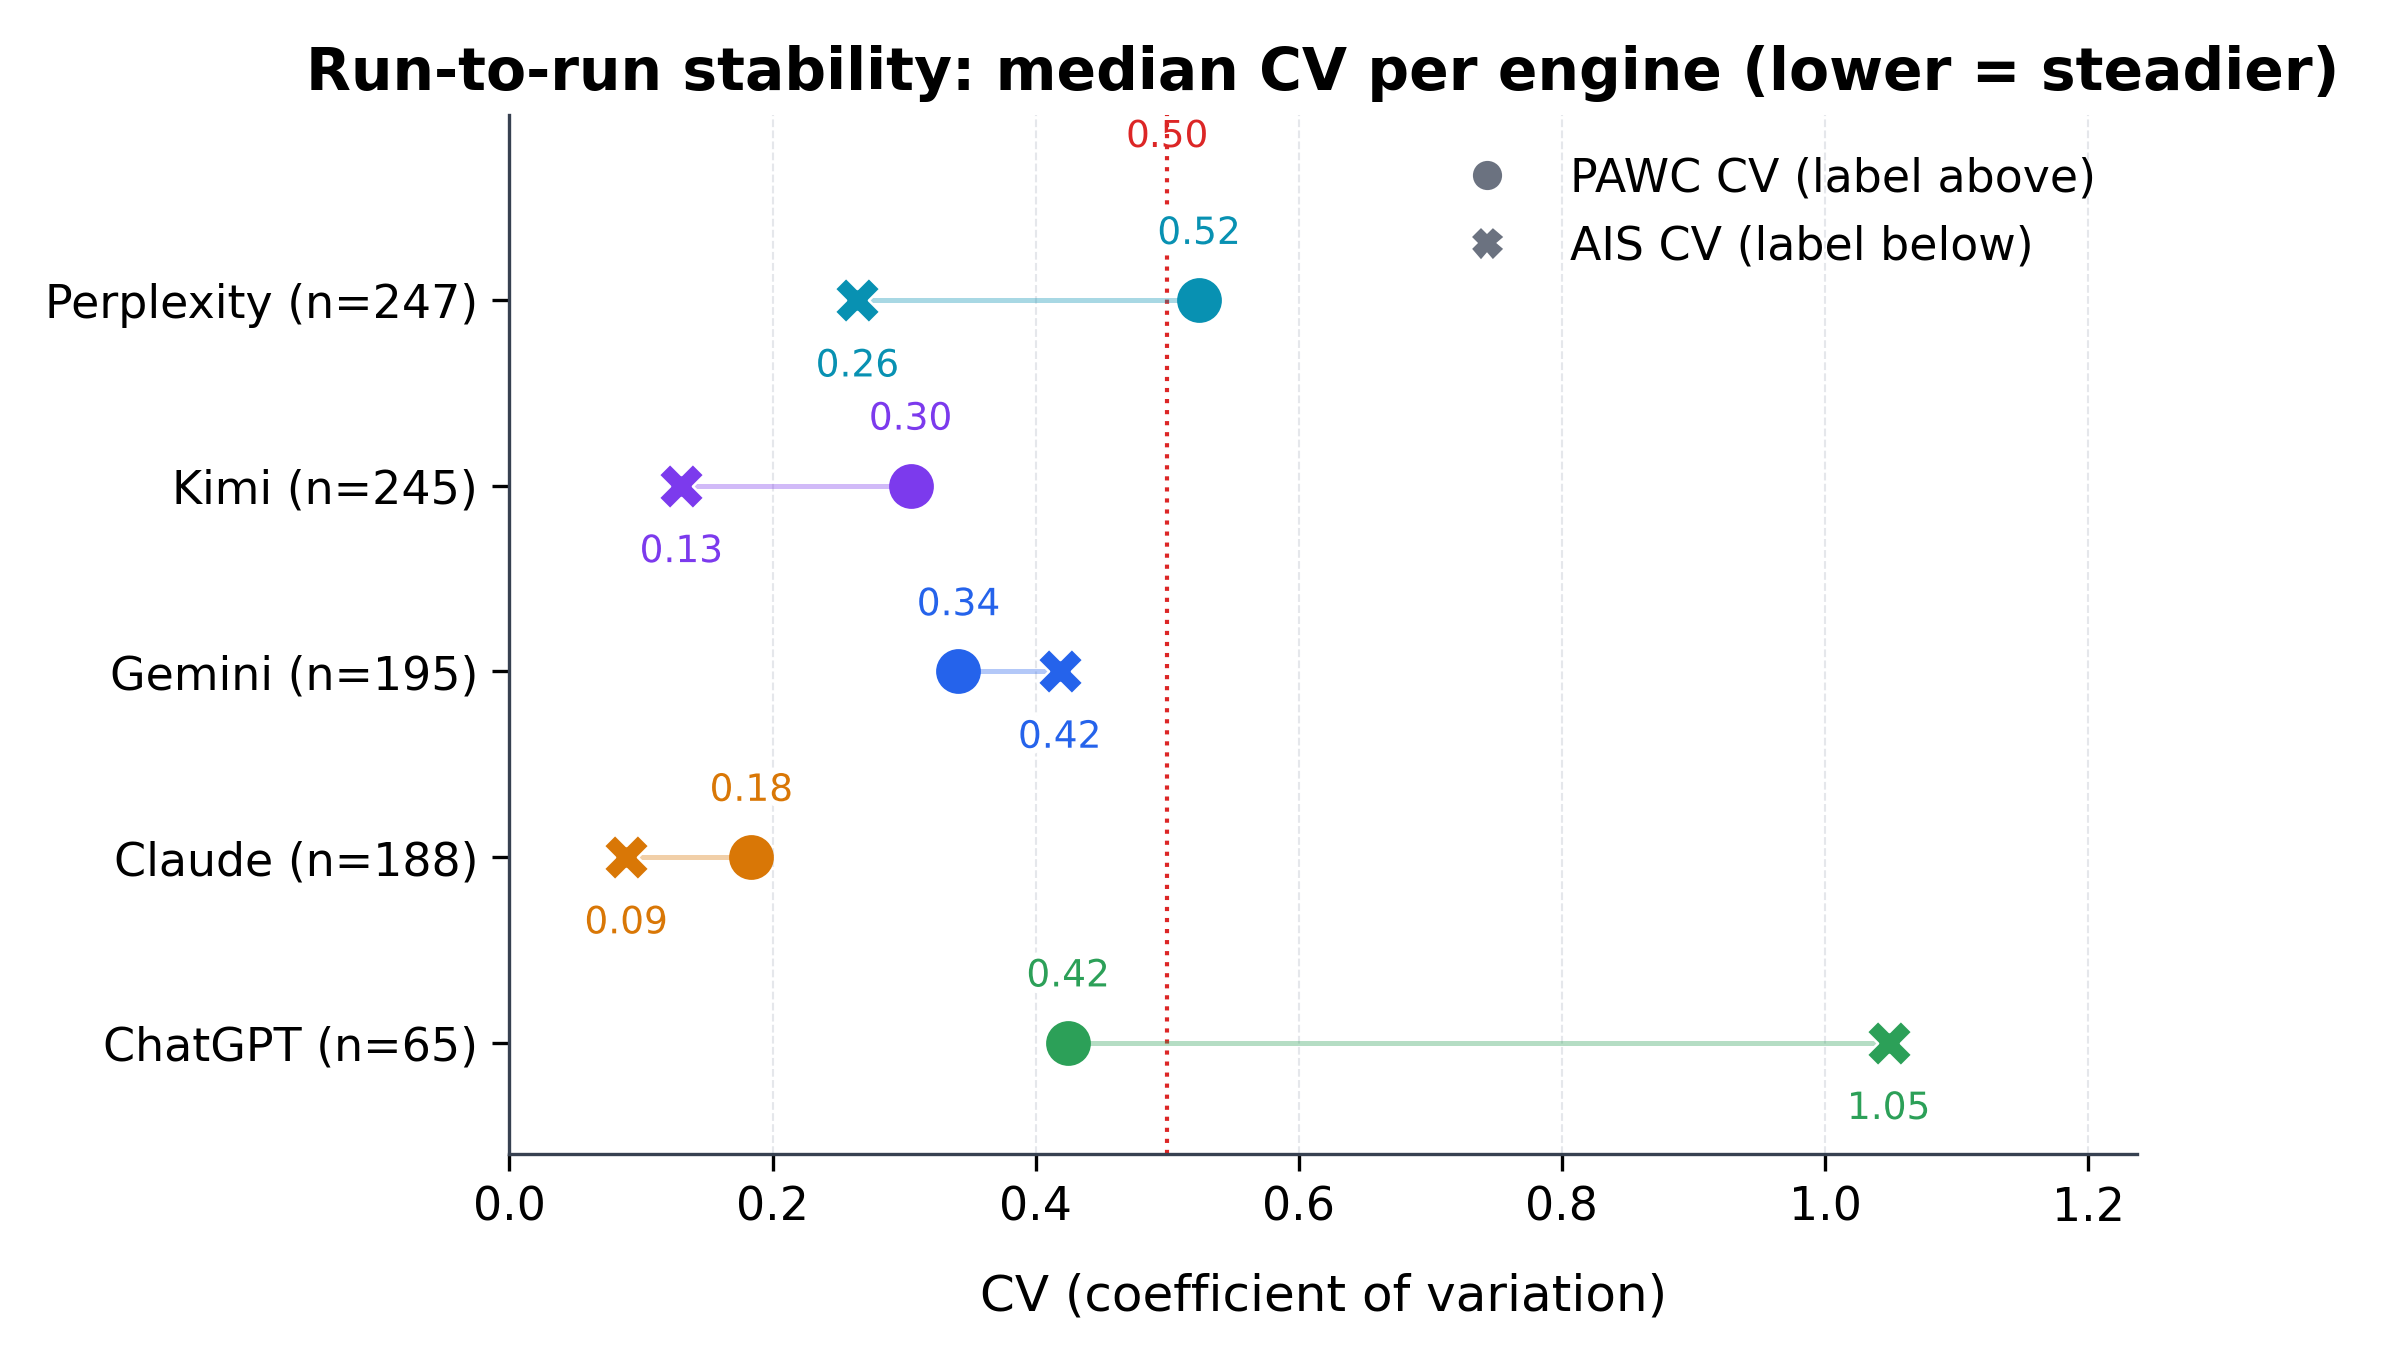

In [2]:
# Q6 · Median PAWC_norm CV vs AIS CV per engine (defined cells: CV not NaN). Dot value labels + n in tick labels.
import matplotlib.patheffects as pe
medp = by_engine(ca.groupby("engine").pawc_norm_cv.median())   # median skips NaN
meda = by_engine(ca.groupby("engine").ais_cv.median())
ndp  = by_engine(ca[ca.pawc_norm_cv.notna()].groupby("engine").size()).fillna(0).astype(int)   # n = defined PAWC_norm CV
nda  = by_engine(ca[ca.ais_cv.notna()].groupby("engine").size()).fillna(0).astype(int)
stroke = [pe.withStroke(linewidth=3, foreground="white")]
fig, ax = plt.subplots()
for y, e in enumerate(ENGINE_ORDER):
    ax.plot([medp[e], meda[e]], [y, y], color=ENGINE_COLOURS[e], alpha=0.35, lw=1.2, zorder=1)
    ax.scatter(medp[e], y, marker="o", s=95, color=ENGINE_COLOURS[e], zorder=3)
    ax.scatter(meda[e], y, marker="X", s=120, color=ENGINE_COLOURS[e], edgecolor="white", linewidth=0.6, zorder=3)
    ax.text(medp[e], y + 0.26, f"{medp[e]:.2f}", ha="center", va="bottom", fontsize=9,
            color=ENGINE_COLOURS[e], path_effects=stroke, zorder=4)                         # PAWC_norm label above
    ax.text(meda[e], y - 0.26, f"{meda[e]:.2f}", ha="center", va="top", fontsize=9,
            color=ENGINE_COLOURS[e], path_effects=stroke, zorder=4)                         # AIS label below
ax.axvline(0.5, color=COLOUR_REFERENCE, lw=1, ls=":", zorder=0)
ax.text(0.5, 4.78, "0.50", color=COLOUR_REFERENCE, fontsize=9, ha="center", va="bottom")
ax.set_yticks(range(5)); ax.set_yticklabels([f"{ENGINE_LABELS[e]} (n={int(ndp[e])})" for e in ENGINE_ORDER])
ax.set_xlabel("CV (coefficient of variation)")
ax.set_title("Run-to-run stability: median CV per engine (lower = steadier)")
ax.set_xlim(0, max(medp.max(), meda.max()) * 1.18); ax.set_ylim(-0.6, 5.0)
ax.legend(handles=[Line2D([], [], marker="o", color=COLOUR_NEUTRAL, ls="", label="PAWC CV (label above)"),
                   Line2D([], [], marker="X", color=COLOUR_NEUTRAL, ls="", label="AIS CV (label below)")],
          loc="upper right")
apply_style(ax); ax.yaxis.grid(False); ax.xaxis.grid(True, color="#E5E7EB", lw=0.5, ls="--")
savefig(fig, "fig_rq2_q6_median_cv_dotplot")

In [3]:
# Validation · Q6 plotted values (median CV + defined-cell counts per engine)
q6_val = pd.DataFrame({"n_defined_pawc": ndp, "median_pawc_cv": medp.round(3),
                       "n_defined_ais": nda, "median_ais_cv": meda.round(3)}).loc[ENGINE_ORDER]
print(q6_val.to_string())

            n_defined_pawc  median_pawc_cv  n_defined_ais  median_ais_cv
engine                                                                  
chatgpt                 65           0.425             77          1.048
claude                 188           0.184            191          0.089
gemini                 195           0.341            215          0.418
kimi                   245           0.305            246          0.131
perplexity             247           0.524            247          0.265


**Key analysis.** ChatGPT produces no measurable visibility score on 74% of queries — 185 of 250 cells are
excluded from this figure, leaving just 65. Even on the cells where it does return an accuracy reading, its
median AIS CV of 1.05 is the highest in the study: the accuracy number swings about as much as the value it is
measuring. Claude is the steadiest engine on both metrics (median PAWC_norm CV 0.18, AIS CV 0.09), though it
too is undefined on a quarter of queries (62 of 250). Never act on a single run on ChatGPT, and average
several runs on every engine before trusting an accuracy number.

saved fig_rq2_q7_cv_band_shares


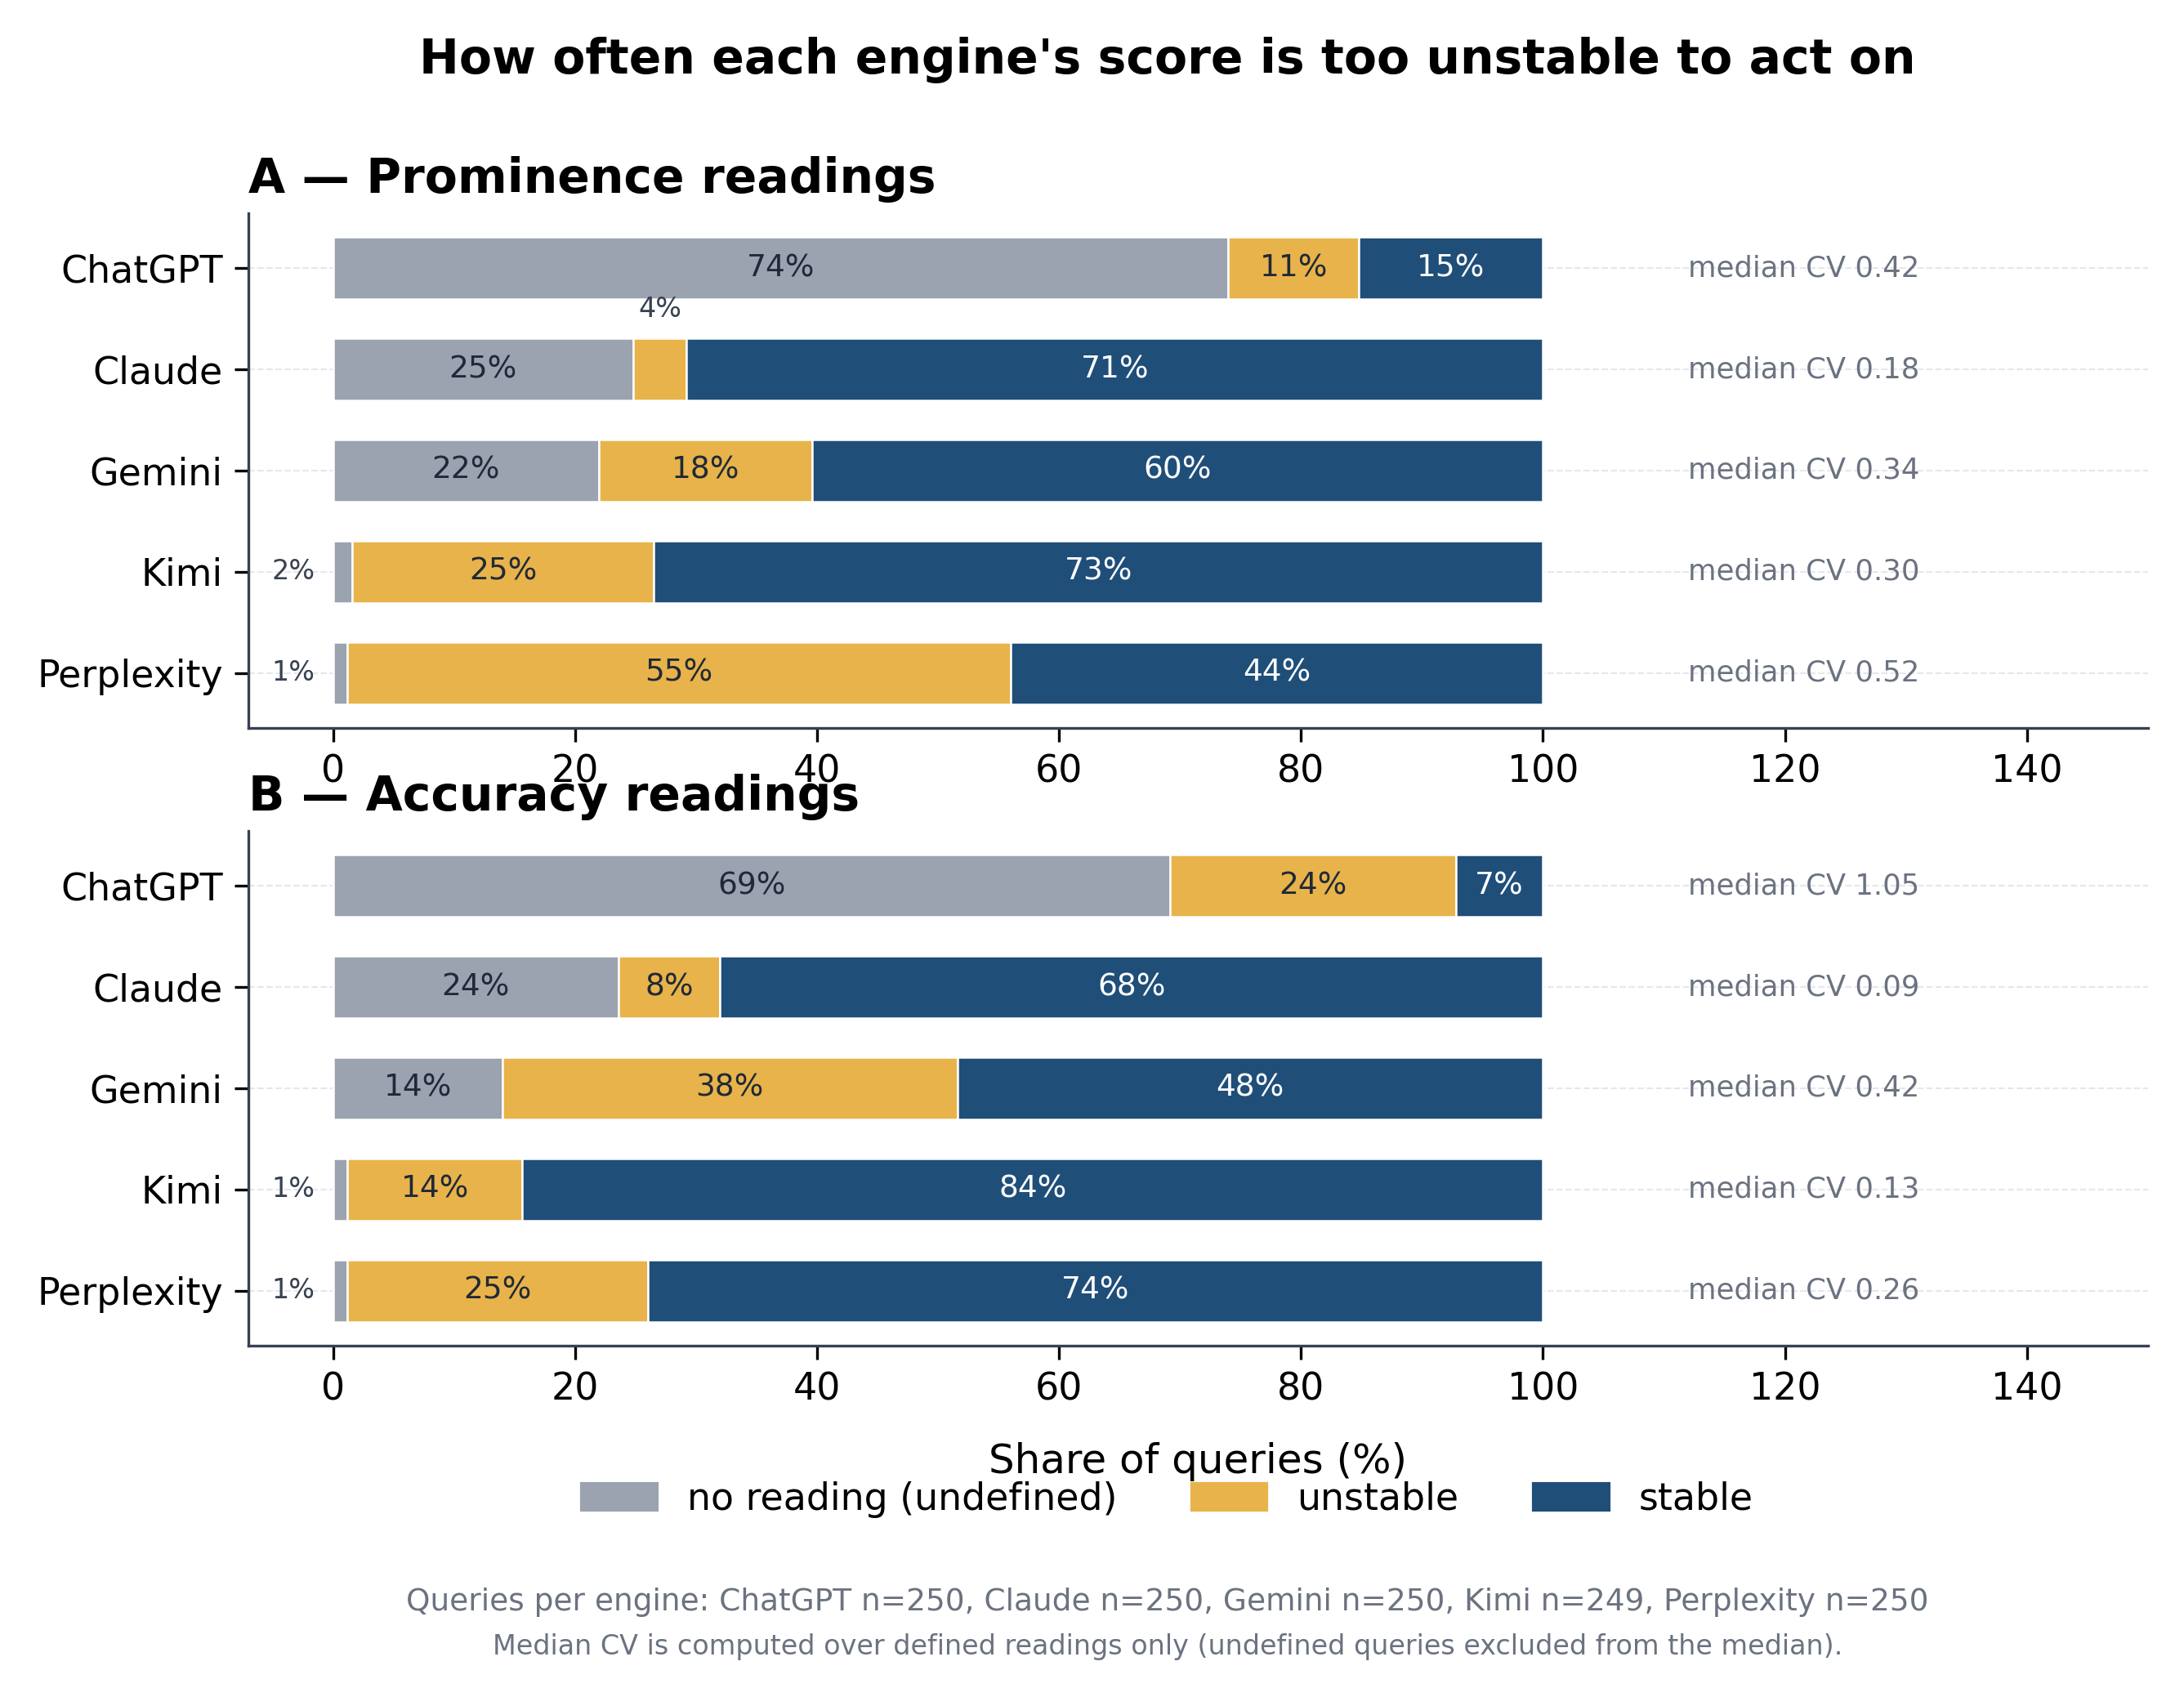

In [4]:
# Q7 · Share of queries by stability band, per engine. Horizontal 100% stacked; worst -> best, left to right.
#   Panel A = prominence stability, Panel B = accuracy stability. Segments: no reading -> unstable -> stable.
#   Right margin: each engine's median CV (same medp/meda series the Q6 dot-plot cell computes).
def bands(m):
    seg = np.where(ca[m].isna(), "undef", np.where(ca[m] < 0.5, "lt", "ge"))
    t = ca.assign(seg=seg).groupby(["engine", "seg"]).size().unstack(fill_value=0).reindex(ENGINE_ORDER)
    for s in ("lt", "ge", "undef"):
        if s not in t: t[s] = 0
    return t
SEG = [("undef", "no reading (undefined)", "#9AA3AF"),
       ("ge",    "unstable",               "#E8B34A"),
       ("lt",    "stable",                 "#1F4E79")]
ntot = by_engine(ca.groupby("engine").size())
ylabs = [ENGINE_LABELS[e] for e in ENGINE_ORDER]
y = np.arange(5)
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for ax, (m, pl, letter, medians) in zip(axes, [("pawc_norm_cv", "Prominence readings", "A", medp),
                                                 ("ais_cv",       "Accuracy readings",   "B", meda)]):
    t = bands(m); frac = (t.div(t.sum(axis=1), axis=0) * 100)
    left = np.zeros(5)
    for key, _, col in SEG:
        w = frac[key].values
        txtcol = "white" if key == "lt" else "#1F2937"
        ax.barh(y, w, left=left, height=0.62, color=col, edgecolor="white", linewidth=0.6)
        for yi in range(5):
            if w[yi] <= 0: continue
            cx = left[yi] + w[yi] / 2
            if w[yi] >= 5:
                ax.text(cx, yi, f"{w[yi]:.0f}%", ha="center", va="center", fontsize=9, color=txtcol)
            elif key == "undef":
                ax.text(-1.5, yi, f"{w[yi]:.0f}%", ha="right", va="center", fontsize=8, color="#374151")
            else:
                ax.text(cx, yi - 0.46, f"{w[yi]:.0f}%", ha="center", va="bottom", fontsize=8, color="#374151")
        left += w
    for yi, e in enumerate(ENGINE_ORDER):
        ax.text(112, yi, f"median CV {medians[e]:.2f}", ha="left", va="center", fontsize=8.5, color="#6B7280")
    ax.set_yticks(y); ax.set_yticklabels(ylabs); ax.invert_yaxis()
    ax.set_xlim(-7, 150); ax.set_title(f"{letter} — {pl}", loc="left")
    apply_style(ax); ax.xaxis.grid(False)
axes[1].set_xlabel("Share of queries (%)")
fig.legend(handles=[Patch(color=c, label=l) for _, l, c in SEG],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("How often each engine's score is too unstable to act on", y=1.0, fontweight="bold", fontsize=14)
fig.text(0.5, -0.07, "Queries per engine: " + ", ".join(f"{ENGINE_LABELS[e]} n={int(ntot[e])}" for e in ENGINE_ORDER),
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
fig.text(0.5, -0.10, "Median CV is computed over defined readings only (undefined queries excluded from the median).",
         ha="center", fontsize=8, color=COLOUR_NEUTRAL)
savefig(fig, "fig_rq2_q7_cv_band_shares")


In [5]:
# Validation · Q7 plotted percentages (engine x panel: undefined / unstable / stable) + median CV
rows = []
for m, panel, medians in [("pawc_norm_cv", "A: PAWC_norm CV", medp), ("ais_cv", "B: AIS CV", meda)]:
    t = bands(m); frac = (t.div(t.sum(axis=1), axis=0) * 100).round(1)
    for e in ENGINE_ORDER:
        rows.append((e, panel, frac.loc[e, "undef"], frac.loc[e, "ge"], frac.loc[e, "lt"], round(medians[e], 3)))
q7_val = pd.DataFrame(rows, columns=["engine", "panel", "pct_undefined", "pct_unstable", "pct_stable", "median_cv"])
print(q7_val.to_string(index=False))


    engine           panel  pct_undefined  pct_unstable  pct_stable  median_cv
   chatgpt A: PAWC_norm CV           74.0          10.8        15.2      0.425
    claude A: PAWC_norm CV           24.8           4.4        70.8      0.184
    gemini A: PAWC_norm CV           22.0          17.6        60.4      0.341
      kimi A: PAWC_norm CV            1.6          24.9        73.5      0.305
perplexity A: PAWC_norm CV            1.2          54.8        44.0      0.524
   chatgpt       B: AIS CV           69.2          23.6         7.2      1.048
    claude       B: AIS CV           23.6           8.4        68.0      0.089
    gemini       B: AIS CV           14.0          37.6        48.4      0.418
      kimi       B: AIS CV            1.2          14.5        84.3      0.131
perplexity       B: AIS CV            1.2          24.8        74.0      0.265


**Key analysis.** ChatGPT's dominant category is "no signal": on 74% of queries it produces nothing measurable
at all — the most severe form of reproducibility failure, because a query that returns no score is worse than
one that returns an unstable score (there is nothing to average). The second finding is Perplexity: it searches
on almost every query (only ~1% undefined), yet **over half of its PAWC_norm readings are unstable (CV ≥ 0.50,
55%)**. Read the red band as worse than the amber, not as a neutral residual — undefined means the engine never
gave you a number, unstable means it gave you one you cannot yet trust. Action: treat single-run PAWC_norm as
provisional, especially on Perplexity and Gemini.

saved fig_rq2_q8_cv_by_searchband


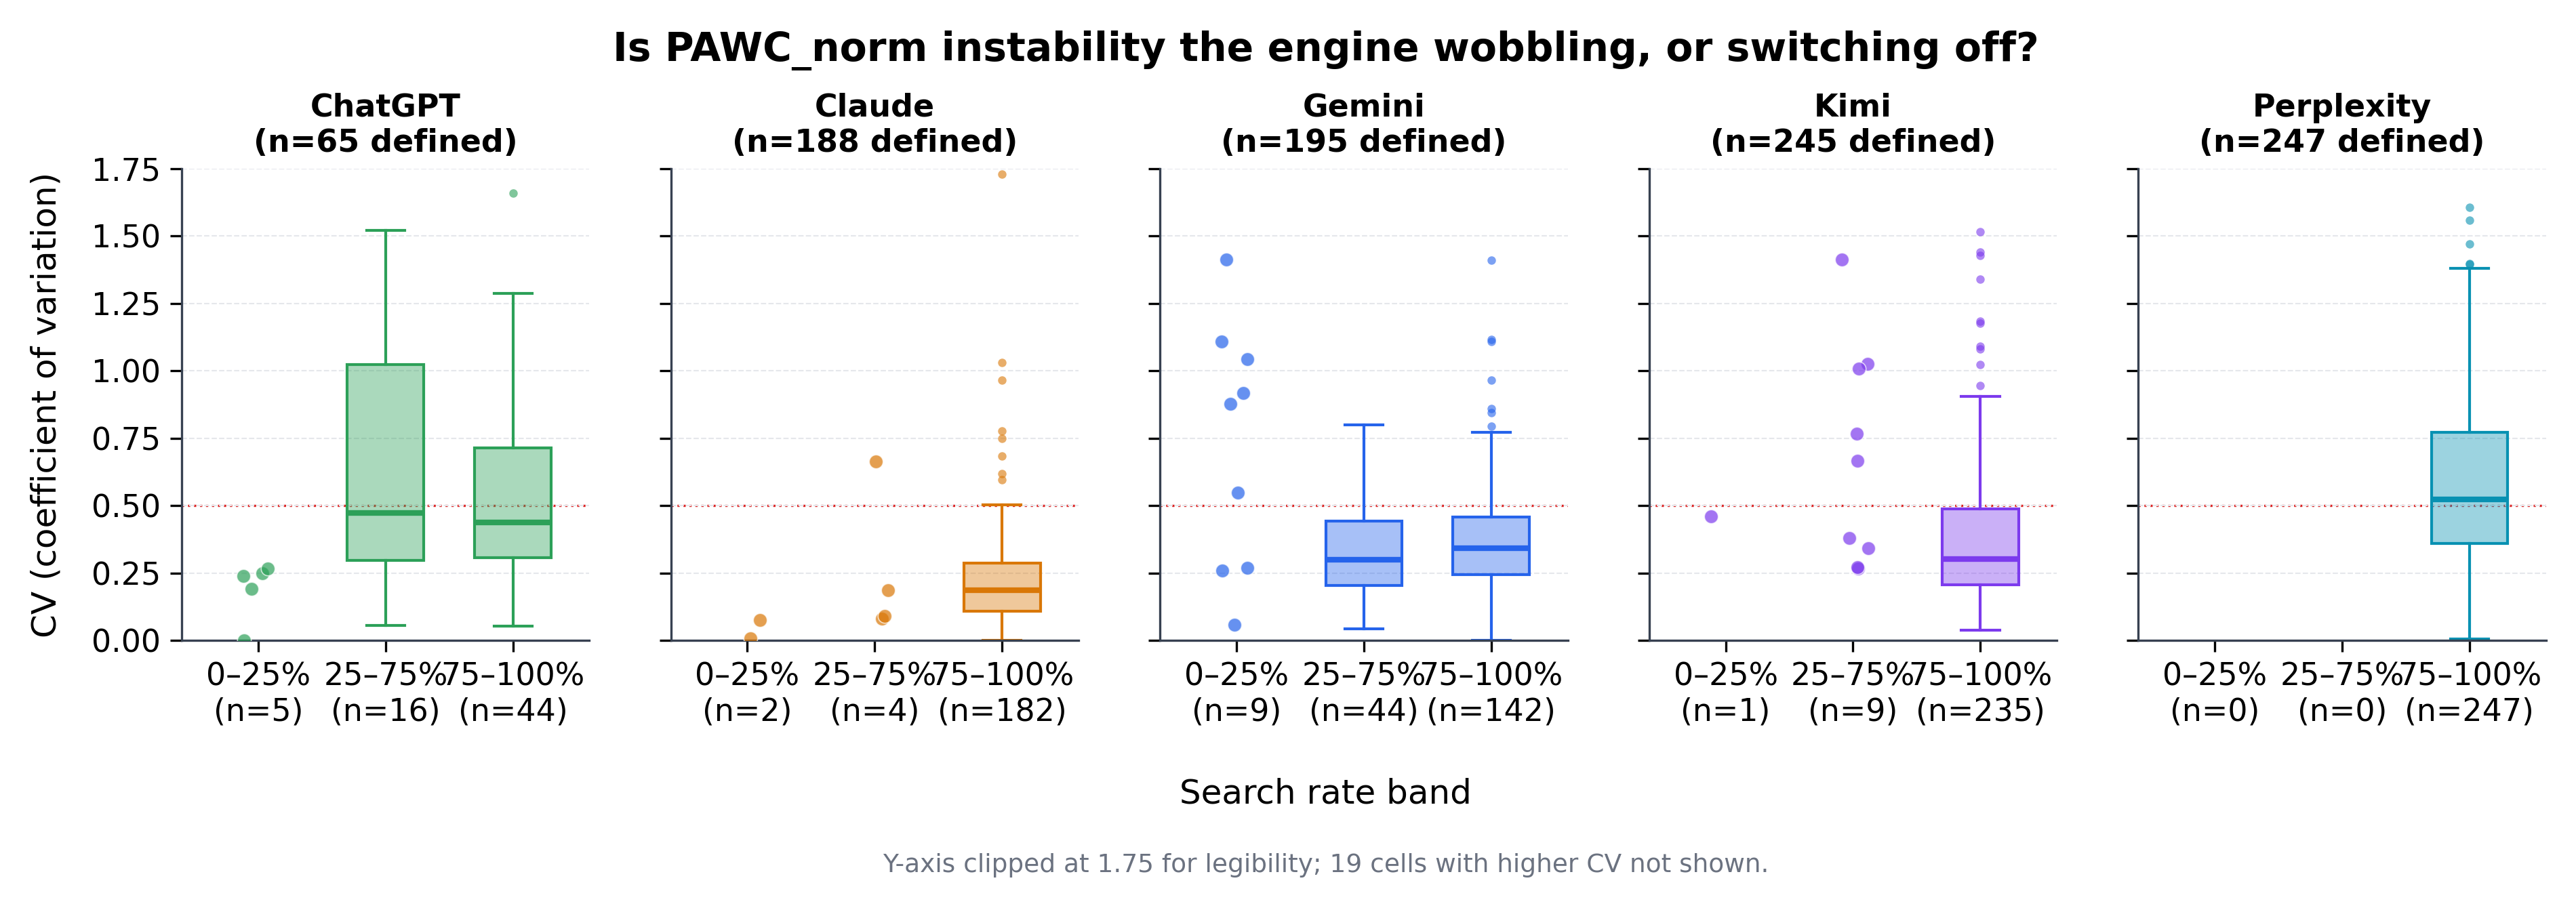

In [6]:
# Q8 · PAWC_norm CV by search-rate band, faceted per engine (defined cells). Box for n>=10, strip plot for n<10.
sub = ca[ca.pawc_norm_cv.notna()].copy()
sub["band"] = pd.cut(sub.did_search_rate, [0, 0.25, 0.75, 1.0], include_lowest=True,
                     labels=["0–25%", "25–75%", "75–100%"])
bnds = ["0–25%", "25–75%", "75–100%"]
YCAP = 1.75
n_clip = int((sub.pawc_norm_cv > YCAP).sum())
ndef = by_engine(sub.groupby("engine").size()).fillna(0).astype(int)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
for ax, e in zip(axes, ENGINE_ORDER):
    de = sub[sub.engine == e]; tlabs = []
    for j, b in enumerate(bnds):
        v = de[de.band == b].pawc_norm_cv.values; n = len(v)
        if n >= 10:
            bp = ax.boxplot(v, positions=[j], widths=0.6, patch_artist=True, showfliers=True)
            bp["boxes"][0].set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS[e], 0.4), edgecolor=ENGINE_COLOURS[e])
            for mm in bp["medians"]: mm.set(color=ENGINE_COLOURS[e], lw=2)
            for wk in bp["whiskers"] + bp["caps"]: wk.set(color=ENGINE_COLOURS[e], lw=1)
            for fl in bp["fliers"]:
                fl.set(marker="o", markersize=3, markerfacecolor=ENGINE_COLOURS[e], markeredgecolor="none", alpha=0.6)
        elif n > 0:                                                    # small-n band: show the actual points
            xj = j + rng.uniform(-0.12, 0.12, n)
            ax.scatter(xj, np.clip(v, None, YCAP), s=24, color=ENGINE_COLOURS[e], alpha=0.7,
                       edgecolor="white", linewidth=0.4, zorder=3)
        tlabs.append(f"{b}\n(n={n})")
    ax.axhline(0.5, color=COLOUR_REFERENCE, lw=0.8, ls=":", zorder=0)
    ax.set_title(f"{ENGINE_LABELS[e]}\n(n={int(ndef[e])} defined)", fontsize=11)
    ax.set_xticks(range(3)); ax.set_xticklabels(tlabs, fontsize=8.5); ax.set_xlim(-0.6, 2.6); apply_style(ax)
axes[0].set_ylim(0, YCAP); axes[0].set_ylabel("CV (coefficient of variation)")
fig.suptitle("Is PAWC_norm instability the engine wobbling, or switching off?", y=1.05, fontweight="bold", fontsize=14)
fig.subplots_adjust(bottom=0.30)
fig.text(0.5, 0.10, "Search rate band", ha="center", fontsize=12)
fig.text(0.5, 0.015, f"Y-axis clipped at {YCAP} for legibility; {n_clip} cells with higher CV not shown.",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
savefig(fig, "fig_rq2_q8_cv_by_searchband")

In [7]:
# Validation · Q8 plotted values (engine x band: n, median CV, mean CV; defined cells)
rows = []
for e in ENGINE_ORDER:
    de = sub[sub.engine == e]
    for b in bnds:
        v = de[de.band == b].pawc_norm_cv.values
        rows.append((e, b, len(v), round(float(np.median(v)), 3) if len(v) else np.nan,
                     round(float(np.mean(v)), 3) if len(v) else np.nan))
q8_val = pd.DataFrame(rows, columns=["engine", "band", "n", "median_cv", "mean_cv"])
print(q8_val.to_string(index=False)); print(f"cells with CV > {YCAP} not shown: {n_clip}")

    engine    band   n  median_cv  mean_cv
   chatgpt   0–25%   5      0.240    0.189
   chatgpt  25–75%  16      0.473    0.646
   chatgpt 75–100%  44      0.437    0.579
    claude   0–25%   2      0.043    0.043
    claude  25–75%   4      0.138    0.255
    claude 75–100% 182      0.185    0.235
    gemini   0–25%   9      0.878    0.722
    gemini  25–75%  44      0.300    0.335
    gemini 75–100% 142      0.342    0.393
      kimi   0–25%   1      0.461    0.461
      kimi  25–75%   9      0.666    0.682
      kimi 75–100% 235      0.302    0.392
perplexity   0–25%   0        NaN      NaN
perplexity  25–75%   0        NaN      NaN
perplexity 75–100% 247      0.524    0.653
cells with CV > 1.75 not shown: 19


**Key analysis.** Each panel asks whether an engine's visibility wobble comes from *sometimes not searching*
(instability piled in the low-search band on the left) or *genuine retrieval variation* (instability even in
the always-searched band on the right). The numbers that matter: **Perplexity always searches (everything sits
in the 75–100% band) yet still shows real spread — true wobble — while Gemini is the clearest "switch-off"
case, with much higher CV when it searches only intermittently (0–25% band) than when it always does**.
ChatGPT barely registers here: it returns no signal on about three-quarters of queries, and those undefined
cells are excluded — so its real problem is not searching rather than wobble. Action: for Perplexity, more
runs is the only fix; for ChatGPT, the bigger issue is getting it to search at all.

saved fig_rq2_q9_engine_agreement_corr


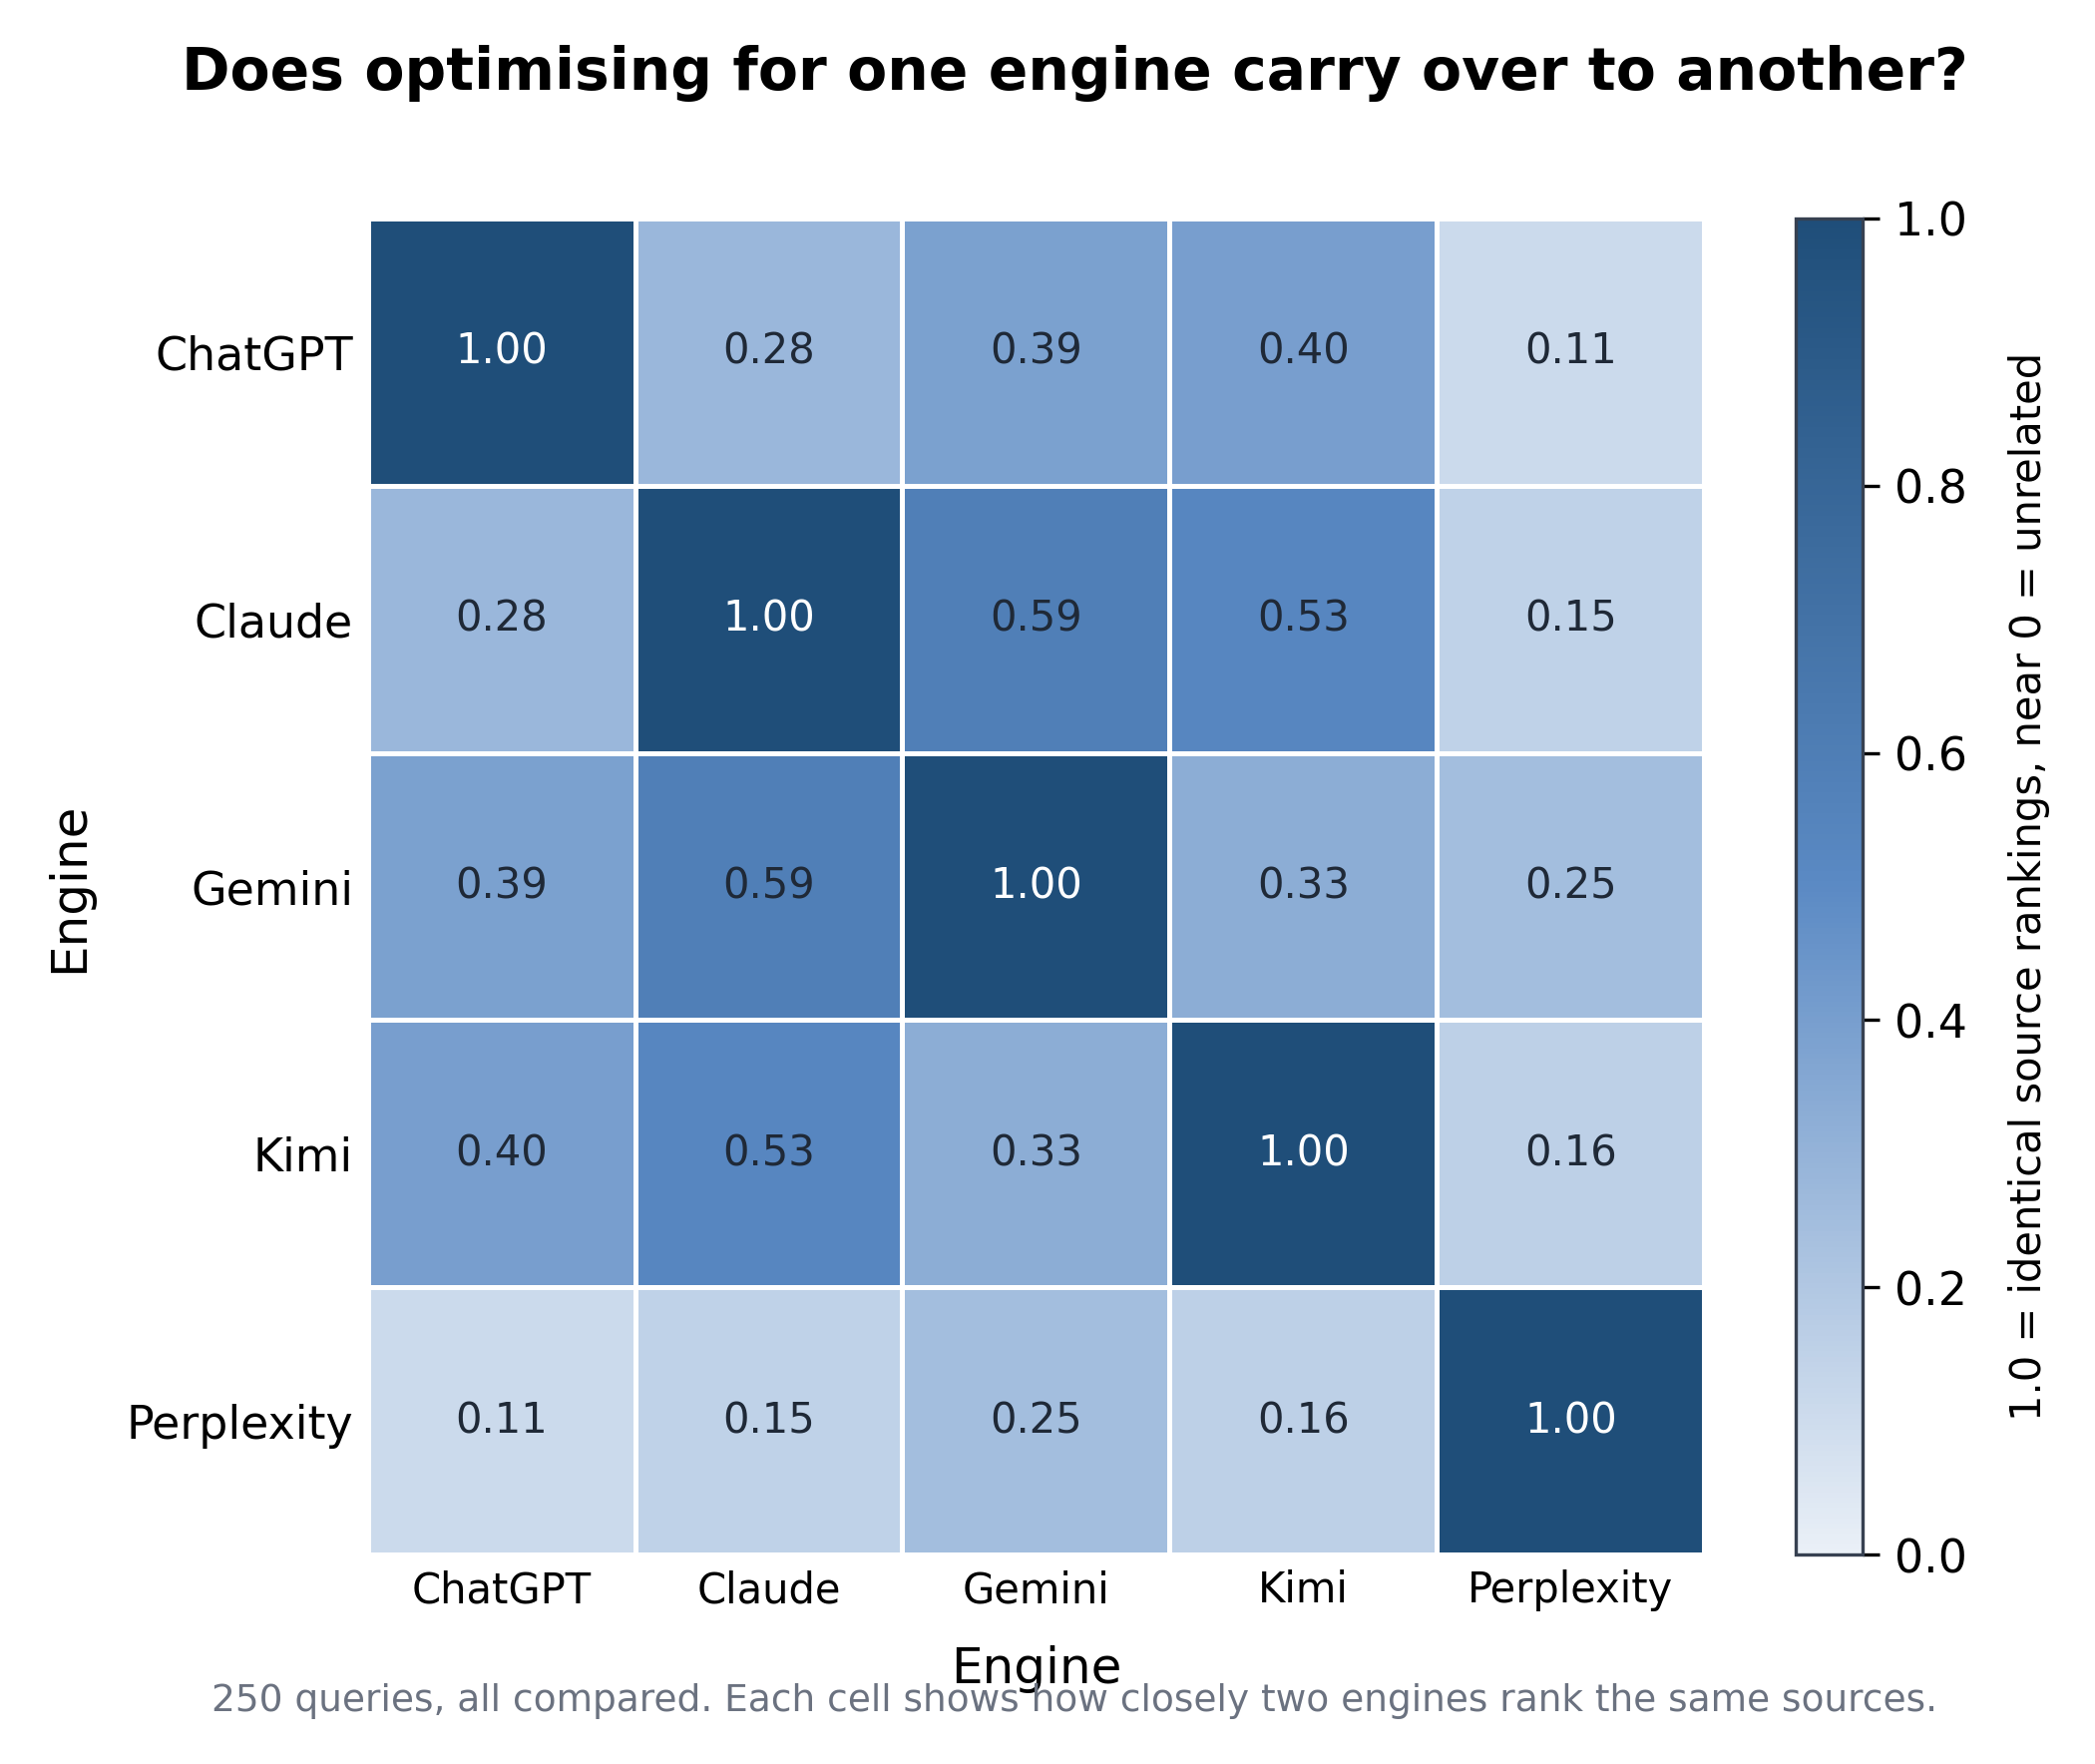

In [8]:
# Q9 · Engine agreement = rank agreement of pawc_norm_mean across queries. Both views are still computed here
#   (unconditional A over 250 q; conditional B where BOTH engines > 0) so the validation cell can report them,
#   but the figure shows ONLY the unconditional panel cited in the Chapter 4 text.
from scipy.stats import spearmanr
piv = ca.pivot(index="query_id", columns="engine", values="pawc_norm_mean").reindex(columns=ENGINE_ORDER)
corr_u = piv.corr(method="spearman")
corr_c = pd.DataFrame(np.nan, index=ENGINE_ORDER, columns=ENGINE_ORDER)
npair  = pd.DataFrame(0, index=ENGINE_ORDER, columns=ENGINE_ORDER)
for a in ENGINE_ORDER:
    for b in ENGINE_ORDER:
        msk = (piv[a] > 0) & (piv[b] > 0); n = int(msk.sum()); npair.loc[a, b] = n
        corr_c.loc[a, b] = 1.0 if a == b else (spearmanr(piv.loc[msk, a], piv.loc[msk, b])[0] if n >= 3 else np.nan)
labels = [ENGINE_LABELS[e] for e in ENGINE_ORDER]
fig, ax = plt.subplots(figsize=(6.6, 5.8))                             # single panel: unconditional (the cited view)
V = corr_u.values.astype(float)
mesh = ax.pcolormesh(V, cmap=CMAP_SEQUENTIAL, vmin=0, vmax=1, edgecolors="white", linewidth=1.2)  # thin gridlines
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xticks(np.arange(5) + 0.5); ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=10)  # horizontal
ax.set_yticks(np.arange(5) + 0.5); ax.set_yticklabels(labels)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
for i in range(5):
    for j in range(5):
        v = V[i, j]
        if np.isnan(v): continue
        ax.text(j + 0.5, i + 0.5, f"{v:.2f}", ha="center", va="center", fontsize=10,
                color="white" if v > 0.6 else "#1F2937")
ax.set_xlabel("Engine", labelpad=8); ax.set_ylabel("Engine", labelpad=8)
fig.suptitle("Does optimising for one engine carry over to another?", y=0.98, fontweight="bold", fontsize=14)
cb = fig.colorbar(mesh, ax=ax, fraction=0.045, pad=0.06)
cb.set_label("1.0 = identical source rankings, near 0 = unrelated", fontsize=10)
fig.text(0.5, 0.02, "250 queries, all compared. Each cell shows how closely two engines rank the same sources.",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
savefig(fig, "fig_rq2_q9_engine_agreement_corr")

In [9]:
# Validation · Q9 correlation matrices + conditional pair counts
print("A — Unconditional Spearman (pawc_norm_mean, 250 queries):"); print(corr_u.round(3).to_string())
print("\nB — Conditional Spearman (both engines pawc_norm_mean > 0):"); print(corr_c.round(3).to_string())
print("\nConditional n (query pairs per cell):"); print(npair.to_string())

A — Unconditional Spearman (pawc_norm_mean, 250 queries):
engine      chatgpt  claude  gemini   kimi  perplexity
engine                                                
chatgpt       1.000   0.278   0.388  0.399       0.110
claude        0.278   1.000   0.588  0.529       0.151
gemini        0.388   0.588   1.000  0.331       0.249
kimi          0.399   0.529   0.331  1.000       0.156
perplexity    0.110   0.151   0.249  0.156       1.000

B — Conditional Spearman (both engines pawc_norm_mean > 0):
            chatgpt  claude  gemini   kimi  perplexity
chatgpt       1.000   0.329   0.463  0.468       0.145
claude        0.329   1.000   0.588  0.529       0.125
gemini        0.463   0.588   1.000  0.331       0.250
kimi          0.468   0.529   0.331  1.000       0.160
perplexity    0.145   0.125   0.250  0.160       1.000

Conditional n (query pairs per cell):
            chatgpt  claude  gemini  kimi  perplexity
chatgpt          77      73      76    76          76
claude           73

**Key analysis.** This matrix answers a practical question: *does optimising for one engine carry over to
another?* Each cell lines up two engines' source-prominence scores across the 250 queries and measures whether
they rise and fall together (1 = identical ordering, 0 = unrelated). The answer is mostly no — the strongest
agreement between any two engines is only moderate (**Claude–Gemini at ρ = 0.59, essentially unchanged (0.59)
when restricted to queries where both engines searched**) and Perplexity barely agrees with anyone
(ρ ≈ 0.11–0.25). Correlations involving ChatGPT are deflated by its 74% zero-prominence rate and lift only
slightly under the conditional view (e.g. ChatGPT–Gemini 0.39 → 0.46), confirming the disagreement is real and
not just an artefact of ChatGPT staying silent. Action: optimise per engine — a source-visibility win on one
engine (say ChatGPT) mostly does not translate into a win on another (say Perplexity).

τ=0.50 AIS: NaN-status identical, per-engine mean reproduces stored (max|Δ|=4.6e-05)
τ=0.50 PAWC_norm: NaN-status identical, per-engine mean reproduces stored (max|Δ|=2.7e-05)

per-engine mean PAWC_norm by τ:
                0.3     0.4     0.5     0.6     0.7
chatgpt     0.9043  0.8192  0.4216  0.3536  0.2996
claude      0.9104  0.8500  0.4256  0.3332  0.2745
gemini      0.7559  0.6839  0.2965  0.2262  0.1816
kimi        0.9222  0.8462  0.3959  0.2913  0.2310
perplexity  0.8248  0.7905  0.4642  0.3748  0.3143

per-engine mean AIS by τ:
                0.3     0.4     0.5     0.6     0.7
chatgpt     0.1985  0.1890  0.1200  0.1012  0.0868
claude      0.7241  0.7177  0.5793  0.5129  0.4597
gemini      0.6653  0.6582  0.5107  0.4415  0.3825
kimi        0.9515  0.9438  0.7774  0.6837  0.6086
perplexity  0.9922  0.9880  0.7930  0.6974  0.6216


saved fig_rq2_q10_rank_by_tau_bump


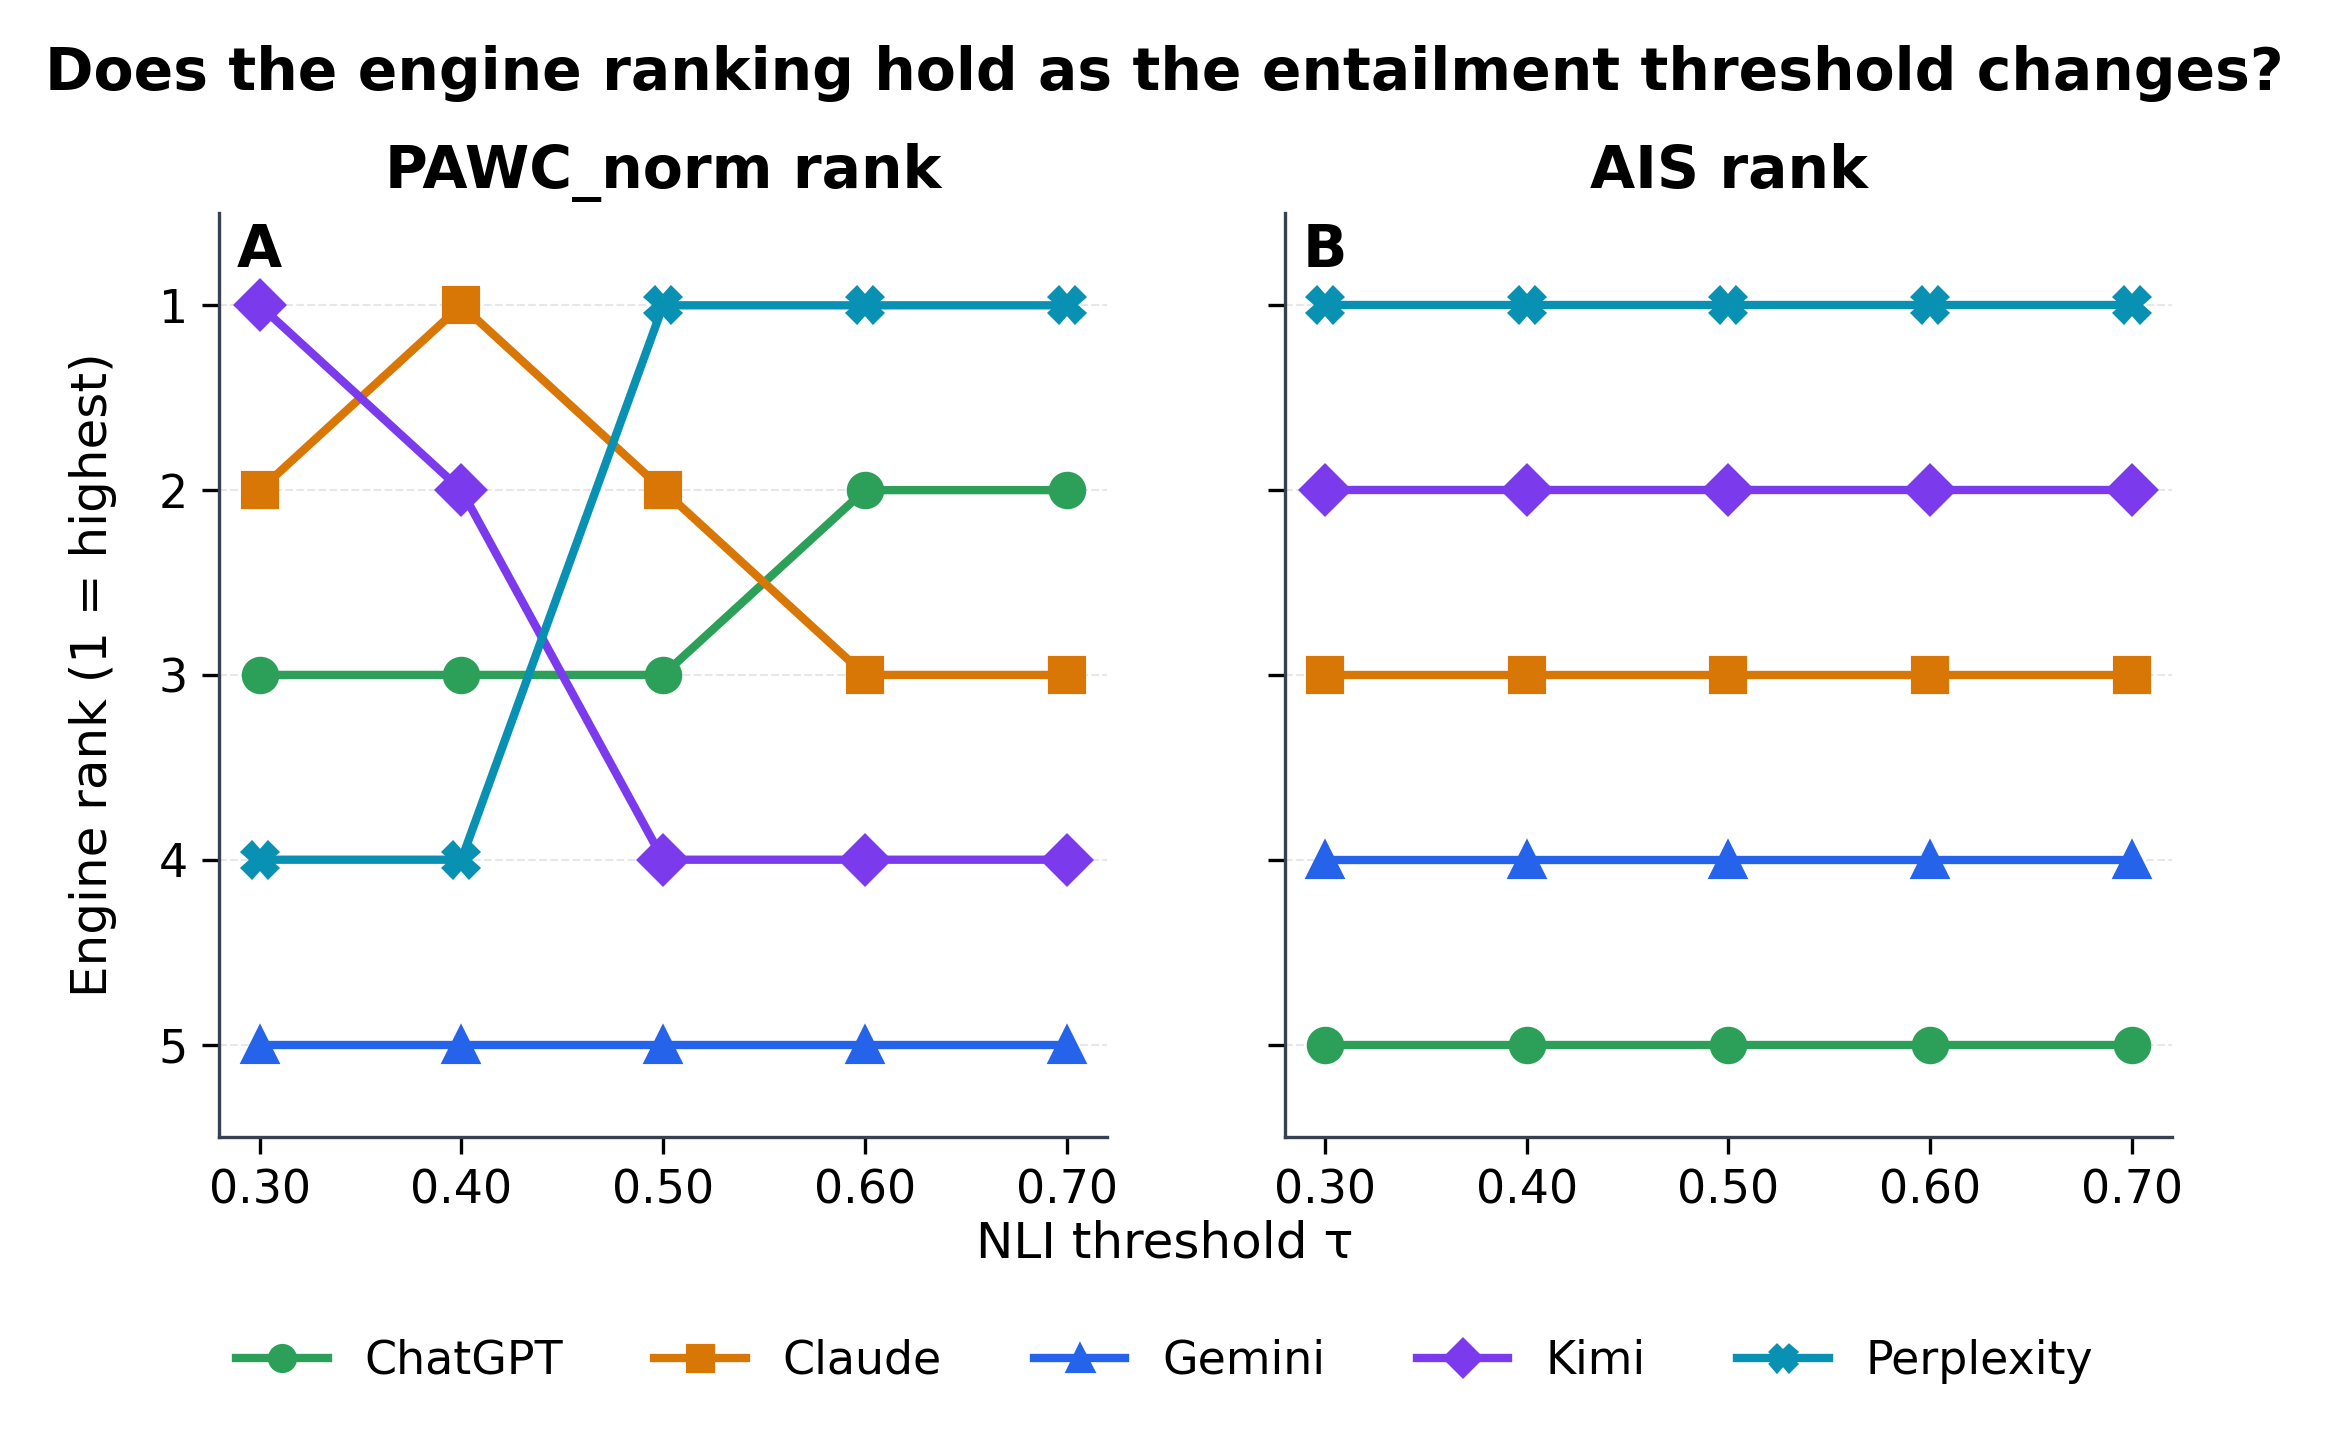

In [10]:
# Q10 · Engine RANK vs NLI threshold τ (reuse sweep helpers). Assert τ=0.50 reproduces stored before plotting.
TAUS = [0.30, 0.40, 0.50, 0.60, 0.70]
# No pre-computed sweep file exists in data/scaleup/gold — recompute from nested sentence_detail (~2–3 s).
surv = [survivors_of(sd) for sd in sil.sentence_detail]
Msrc = sil.n_sources_fetched_ok.astype(int).to_numpy(); eg = sil.engine.to_numpy()
ais = {t: np.array([metrics_at(s, m, t)[0] for s, m in zip(surv, Msrc)]) for t in TAUS}
nrm = {t: np.array([metrics_at(s, m, t)[1] for s, m in zip(surv, Msrc)]) for t in TAUS}
for nm, rec, stored in [("AIS", ais[0.50], sil.cleaned_ais.to_numpy()), ("PAWC_norm", nrm[0.50], sil.pawc_norm.to_numpy())]:
    assert (np.isnan(rec) == np.isnan(stored)).all(), nm + " NaN-status mismatch"
    dmean = max(abs(np.nanmean(rec[eg == e]) - np.nanmean(stored[eg == e])) for e in ENGINE_ORDER)
    assert dmean < 2e-3, (nm, dmean)
    print(f"τ=0.50 {nm}: NaN-status identical, per-engine mean reproduces stored (max|Δ|={dmean:.1e})")
mean_tab = lambda Mx: pd.DataFrame({t: [np.nanmean(Mx[t][eg == e]) for e in ENGINE_ORDER] for t in TAUS}, index=ENGINE_ORDER)
print("\nper-engine mean PAWC_norm by τ:\n", mean_tab(nrm).round(4).to_string())
print("\nper-engine mean AIS by τ:\n", mean_tab(ais).round(4).to_string())
def rank_table(metric):
    mean = pd.DataFrame({t: [np.nanmean(metric[t][eg == e]) for e in ENGINE_ORDER] for t in TAUS}, index=ENGINE_ORDER)
    return mean.rank(ascending=False)
rP, rA = rank_table(nrm), rank_table(ais)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.0), sharey=True)
for ax, (rk, pl, letter) in zip(axes, [(rP, "PAWC_norm rank", "A"), (rA, "AIS rank", "B")]):
    for e in ENGINE_ORDER:
        ax.plot(range(5), rk.loc[e].values, marker=ENGINE_MARKERS[e], color=ENGINE_COLOURS[e], lw=2, ms=8)
    ax.set_xticks(range(5)); ax.set_xticklabels([f"{t:.2f}" for t in TAUS])
    ax.set_yticks(range(1, 6)); ax.set_ylim(5.5, 0.5); ax.set_title(pl)
    apply_style(ax); ax.yaxis.grid(True, color="#E5E7EB", lw=0.5, ls="--")
    ax.text(0.02, 0.99, letter, transform=ax.transAxes, fontsize=14, fontweight="bold", va="top")
axes[0].set_ylabel("Engine rank (1 = highest)")
fig.text(0.5, 0.01, "NLI threshold τ", ha="center", fontsize=12)
fig.legend(handles=[Line2D([], [], marker=ENGINE_MARKERS[e], color=ENGINE_COLOURS[e], lw=2, label=ENGINE_LABELS[e])
                    for e in ENGINE_ORDER], loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.13))
fig.suptitle("Does the engine ranking hold as the entailment threshold changes?", y=1.02, fontweight="bold", fontsize=14)
savefig(fig, "fig_rq2_q10_rank_by_tau_bump")

**Key analysis.** Each line tracks an engine's rank as the AI judge's "is this really supported?" threshold is
tightened from 0.30 to 0.70. The number that matters: **the accuracy (AIS) ranking never moves across the entire
sweep — Perplexity 1st and Kimi 2nd at every τ — while the visibility (PAWC_norm) ranking is threshold-sensitive**:
Kimi falls from 1st (τ = 0.30) to 4th (τ ≥ 0.50) as Perplexity climbs from 4th to 1st, and above 0.50 ChatGPT and
Claude swap 2nd and 3rd. Always report the NLI threshold (τ) alongside any PAWC_norm league table; at τ = 0.50
Perplexity leads, but the ordering is not a fixed truth. Trust accuracy-based engine comparisons, which the
threshold does not touch.

---
## Q11 — Mechanical CV ceiling (AIS CV) at k = 8 vs k = 3

Ceiling definition **confirmed**: the mechanical maximum of a coefficient of variation computed with sample
standard deviation (ddof=1) over k non-negative runs is **√k** (√8 ≈ 2.828 at k=8; √3 ≈ 1.732 at k=3),
reached only by the degenerate "one run non-zero, the rest zero" pattern. A cell is **on the ceiling** when its
AIS CV is within ε (1e-6) of √k. AIS CV is used because it is the only CV present in **both** the pilot (k=3)
and scale-up (k=8) gold tables; the two files differ in query sample (pilot 100, scale-up 250), so this is a
k-effect comparison rather than a controlled one.

on-ceiling % — k=8: {'chatgpt': 4.8, 'claude': 1.2, 'gemini': 8.4, 'kimi': 1.2, 'perplexity': 0.8} | k=3: {'chatgpt': 9.0, 'claude': 4.0, 'gemini': 10.0, 'kimi': 2.0, 'perplexity': 10.0}


saved fig_rq2_q11_cv_ceiling_k8_vs_k3


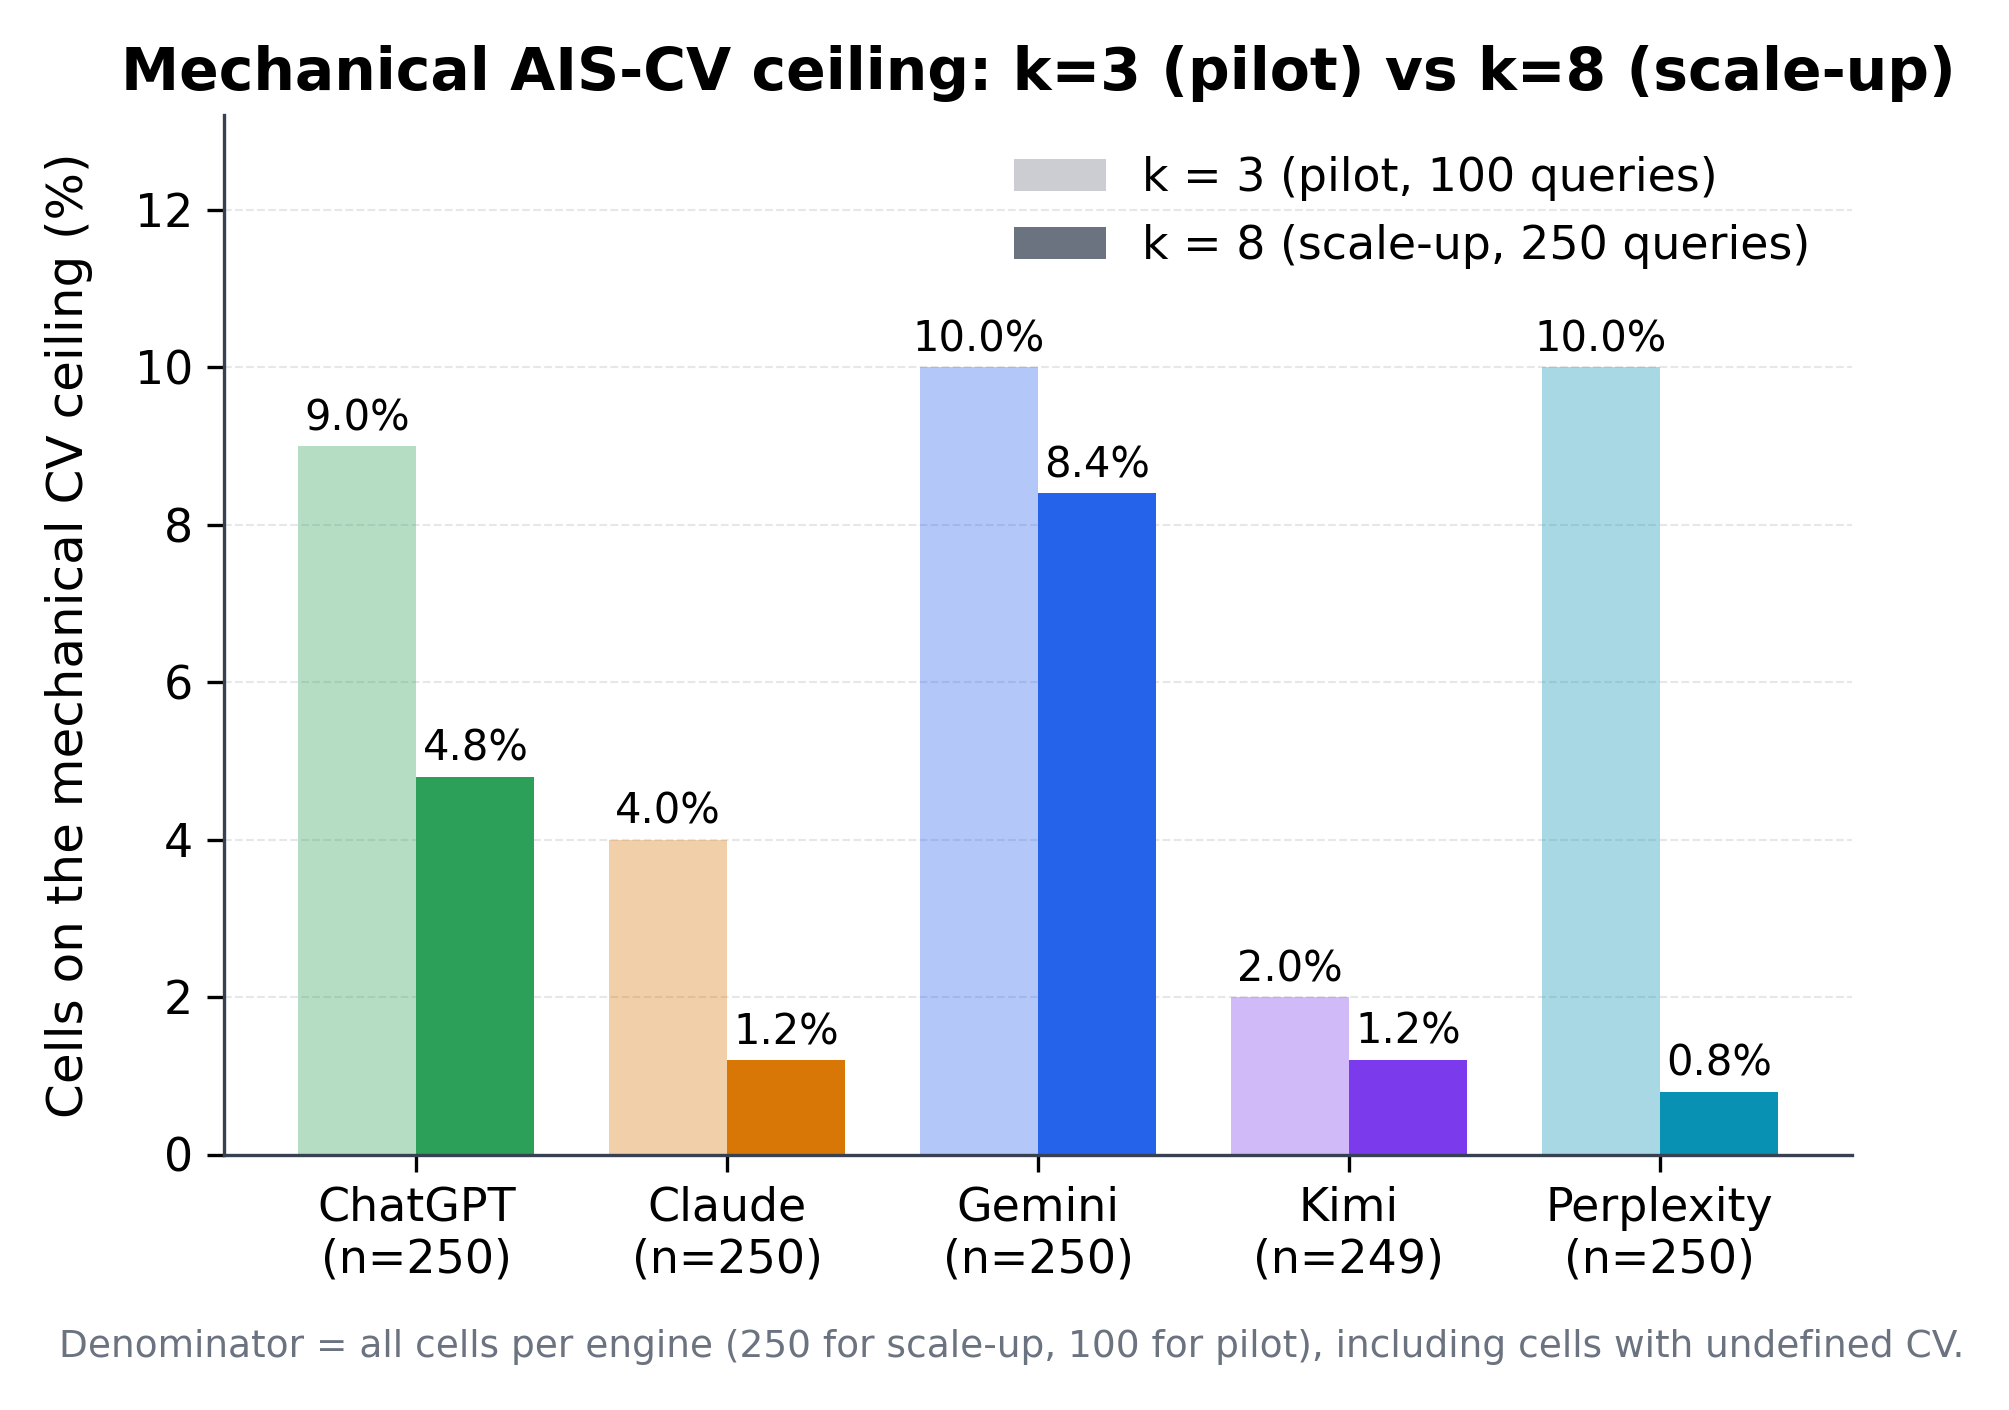

In [11]:
# Q11 · Proportion of cells on the mechanical AIS-CV ceiling: k=8 (scale-up) vs k=3 (pilot).
# Ceiling = max CV of a non-negative metric over k runs with SAMPLE sd (ddof=1) = sqrt(k); reached only by the
#   degenerate "one run non-zero, rest zero" pattern. 'On ceiling' = |ais_cv - sqrt(k)| < 1e-6.
pil = pd.read_parquet("../../data/pilot/gold/cell_aggregates_pilot.parquet")     # pilot k=3, 500 cells (100 q x 5)
EPS = 1e-6
def ceiling_share(df, k):
    c = np.sqrt(k); on = df.ais_cv.notna() & ((df.ais_cv - c).abs() < EPS)
    return by_engine(df.assign(on=on).groupby("engine").on.mean())
assert abs(ca.ais_cv.max() - np.sqrt(8)) < EPS and abs(pil.ais_cv.max() - np.sqrt(3)) < EPS   # ceiling reached in both
f8, f3 = ceiling_share(ca, 8), ceiling_share(pil, 3)
n8 = by_engine(ca.groupby("engine").size()).astype(int)
print("on-ceiling % — k=8:", (f8 * 100).round(1).to_dict(), "| k=3:", (f3 * 100).round(1).to_dict())
x = np.arange(5); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, f3.values * 100, w, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER], alpha=0.35)   # k=3 faded
ax.bar(x + w/2, f8.values * 100, w, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER])               # k=8 solid
for xi, (a, b) in enumerate(zip(f3.values, f8.values)):
    ax.text(xi - w/2, a*100 + 0.2, f"{a*100:.1f}%", ha="center", fontsize=10)
    ax.text(xi + w/2, b*100 + 0.2, f"{b*100:.1f}%", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels([f"{ENGINE_LABELS[e]}\n(n={int(n8[e])})" for e in ENGINE_ORDER])
ax.set_ylabel("Cells on the mechanical CV ceiling (%)")
ax.set_title("Mechanical AIS-CV ceiling: k=3 (pilot) vs k=8 (scale-up)")
ax.set_ylim(0, max(f3.max(), f8.max()) * 100 * 1.32)
ax.legend(handles=[Patch(facecolor=COLOUR_NEUTRAL, alpha=0.35, label="k = 3 (pilot, 100 queries)"),
                   Patch(facecolor=COLOUR_NEUTRAL, label="k = 8 (scale-up, 250 queries)")], loc="upper right")
apply_style(ax)
fig.text(0.5, -0.04, "Denominator = all cells per engine (250 for scale-up, 100 for pilot), including cells with undefined CV.",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
savefig(fig, "fig_rq2_q11_cv_ceiling_k8_vs_k3")

**Key analysis.** A cell sits on the "mechanical ceiling" when its accuracy score is identical across all but
one run — the most extreme run-to-run swing the maths allows, i.e. pure artefact rather than signal. This
comparison is indicative rather than controlled: the pilot used 100 queries and the scale-up a different 250,
so the reduction reflects both the additional runs and a different query mix. Even so, every engine improves —
**Gemini drops from 10.0% to 8.4%, Perplexity from 10.0% to 0.8%**, ChatGPT from 9.0% to 4.8%. Action: three
runs is too few to trust a per-query score; treat about eight runs as the minimum viable check count.